### FIRST OF ALL WE NEED TO IMPORT LIBRARIES

   age  gender   bmi alcohol_consumption smoking_status  hepatitis_b  \
0   68  Female  18.1             Regular         Former            0   
1   81  Female  19.9          Occasional          Never            0   
2   58  Female  25.5               Never          Never            0   
3   44    Male  16.0               Never         Former            0   
4   72    Male  21.0          Occasional         Former            0   

   hepatitis_c  liver_function_score  alpha_fetoprotein_level  \
0            0                  51.9                    16.44   
1            0                  41.6                     8.09   
2            0                  76.0                     0.64   
3            0                  50.3                    19.09   
4            0                  39.5                     4.95   

   cirrhosis_history  family_history_cancer physical_activity_level  diabetes  \
0                  0                      0                     Low         0   
1             

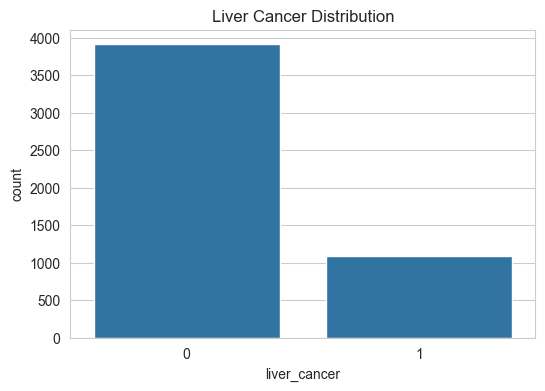

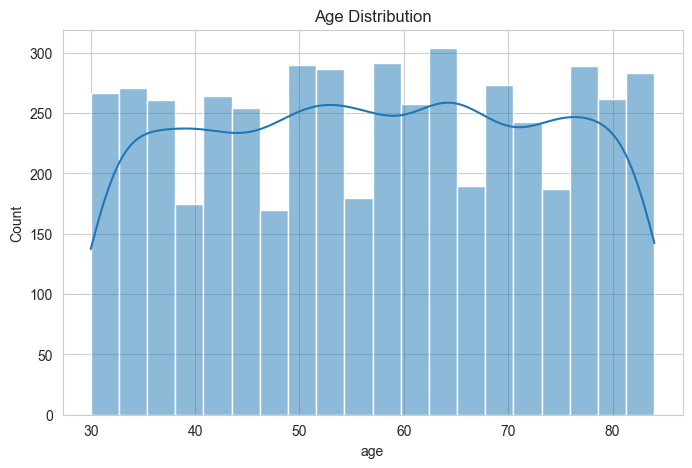

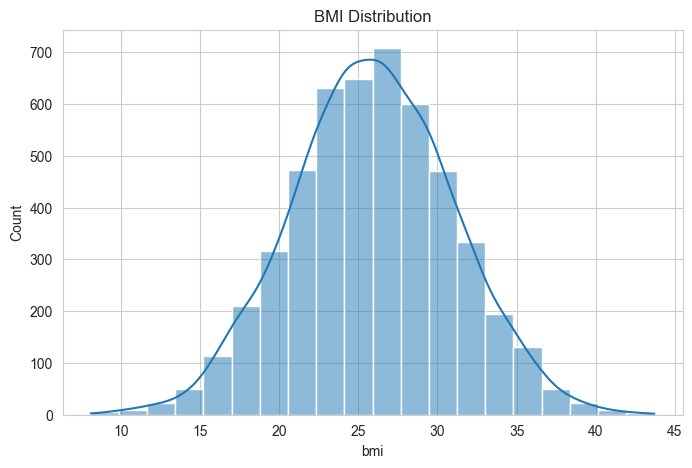

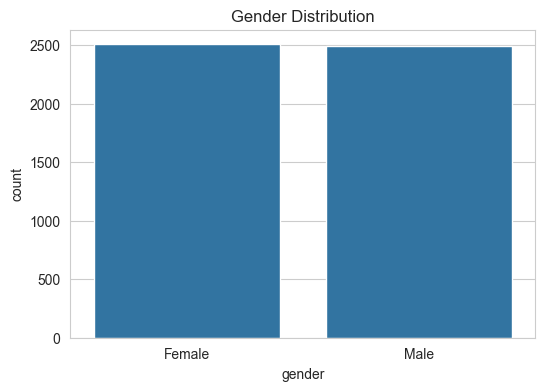

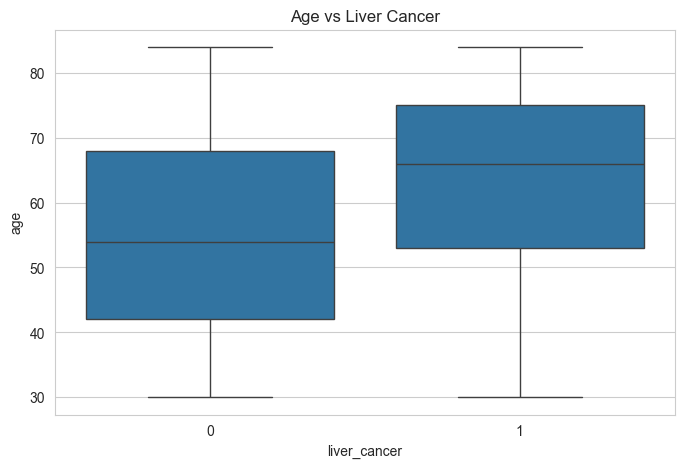

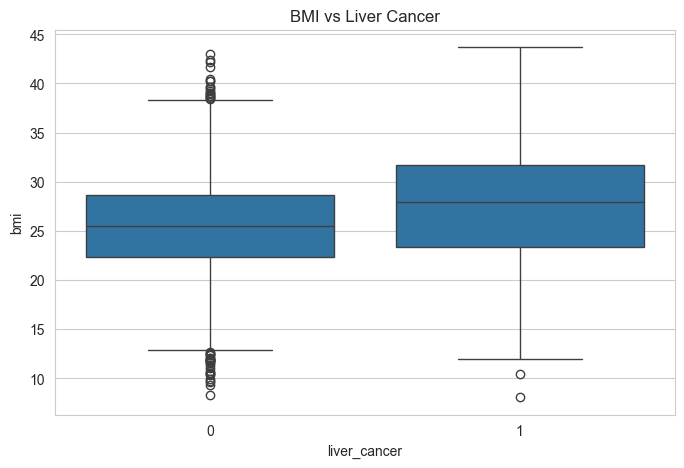

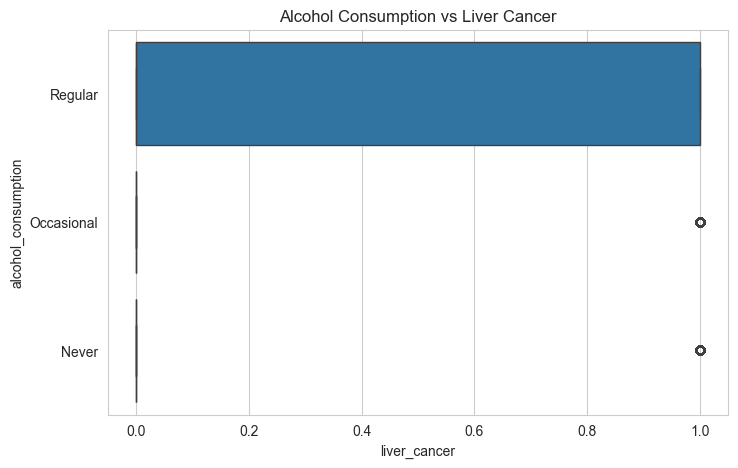

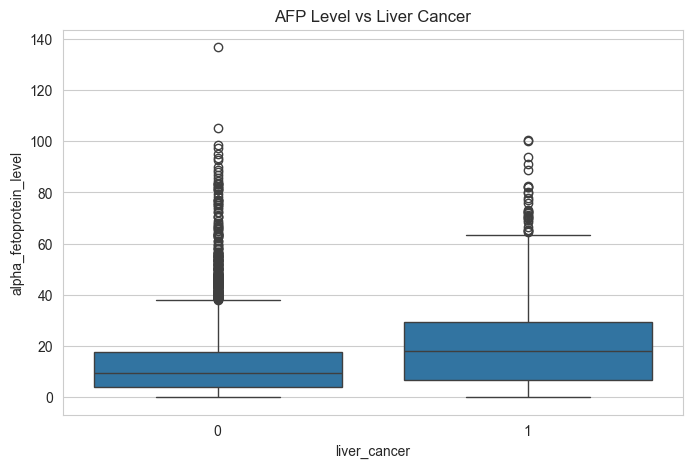

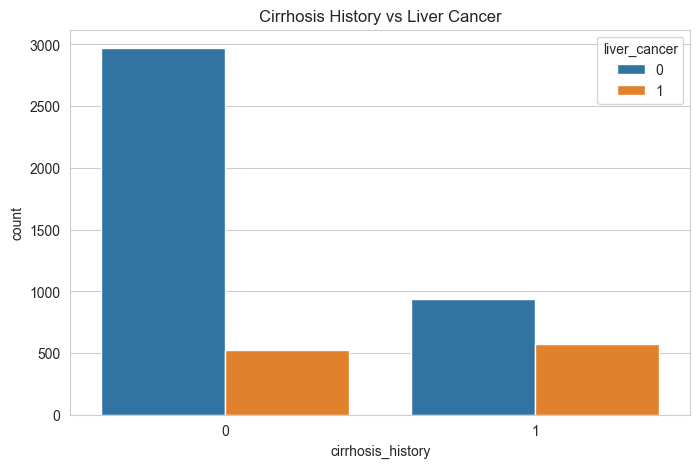

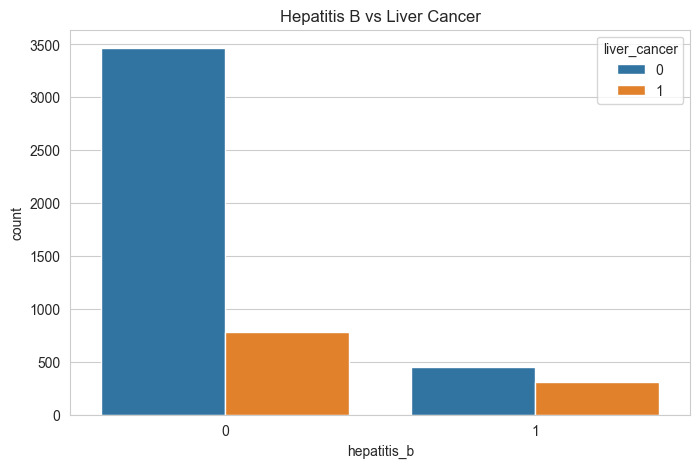

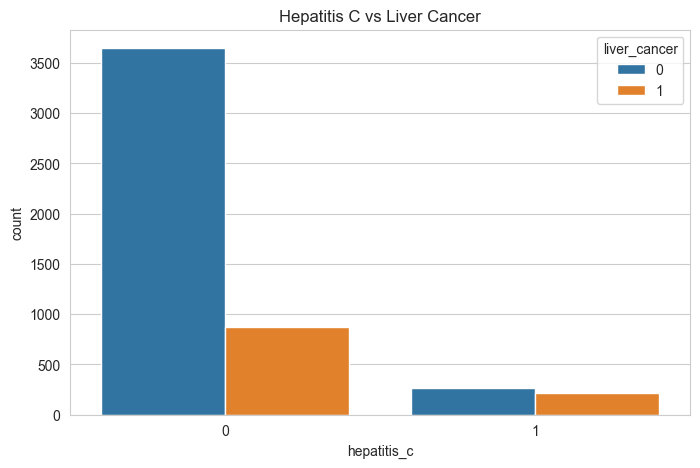

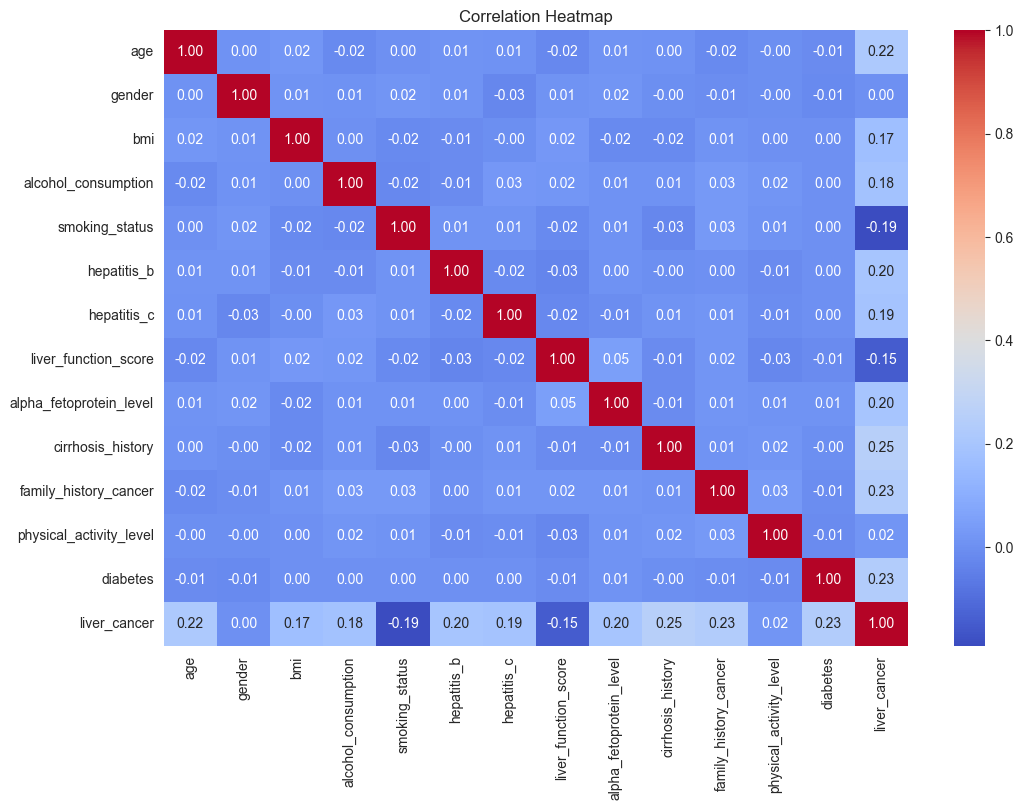



Logistic Regression
Accuracy: 0.905

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       782
           1       0.82      0.73      0.77       218

    accuracy                           0.91      1000
   macro avg       0.87      0.84      0.86      1000
weighted avg       0.90      0.91      0.90      1000



Decision Tree
Accuracy: 0.907

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       782
           1       0.78      0.80      0.79       218

    accuracy                           0.91      1000
   macro avg       0.86      0.87      0.86      1000
weighted avg       0.91      0.91      0.91      1000



Random Forest
Accuracy: 0.939

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       782
           1       0.95      0.76      0.84       218

    accurac

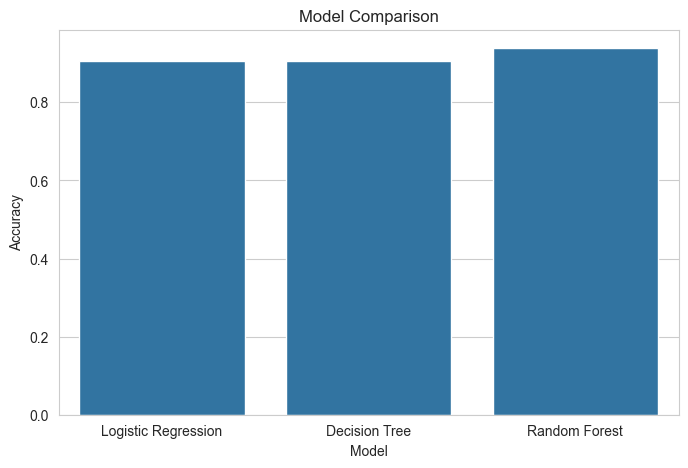

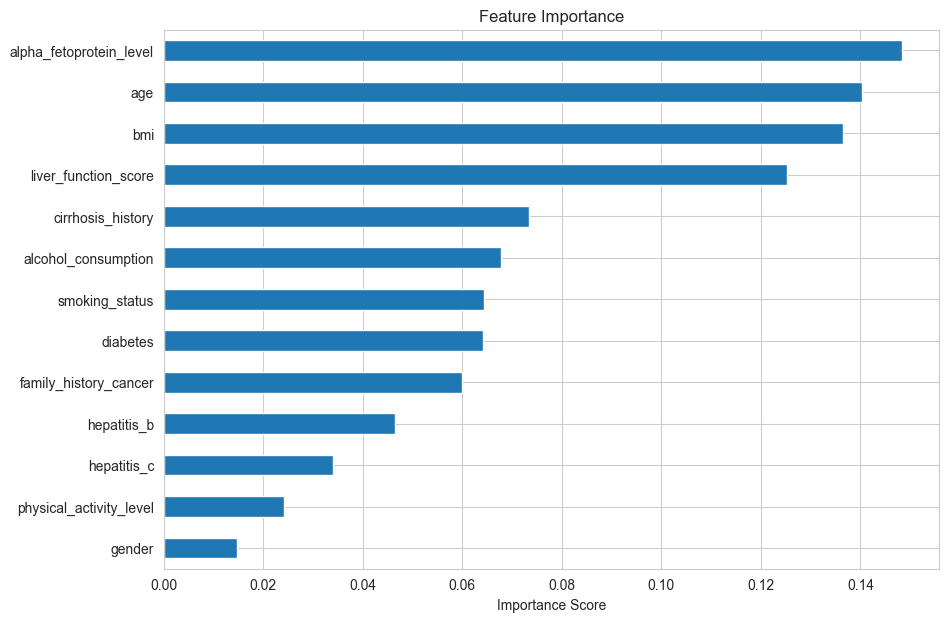

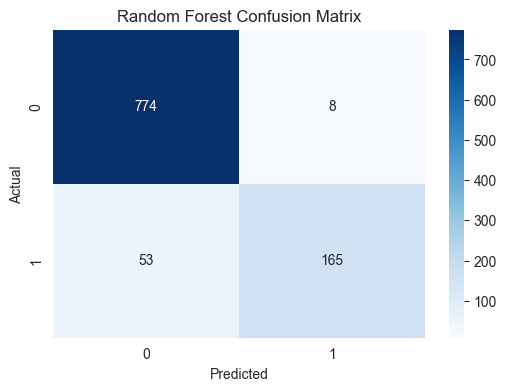

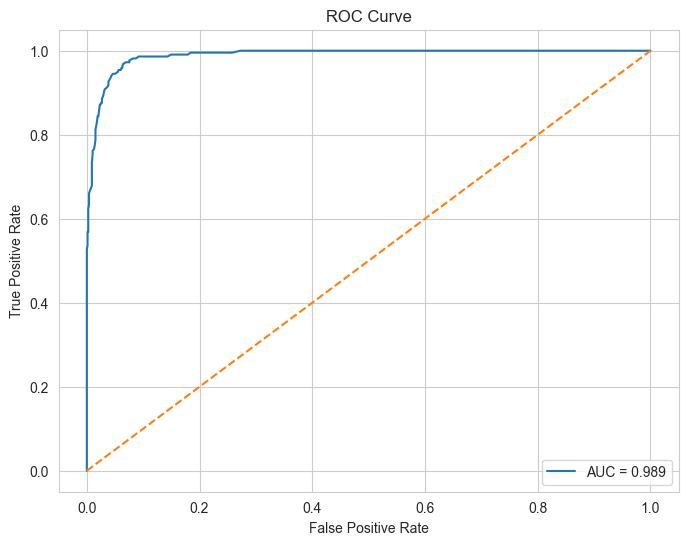


Project Completed Successfully


In [37]:


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# =====================
# 2. LOAD DATASET
# =====================

df = pd.read_csv("liver_cancer.xls")

print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Info:")
print(df.info())

# =====================
# 3. DATA CLEANING
# =====================

print("\nMissing Values")
print(df.isnull().sum())

df.drop_duplicates(inplace=True)

print("\nDuplicates Removed")

# =====================
# 4. EDA
# =====================

sns.set_style("whitegrid")

# Target Distribution

plt.figure(figsize=(6,4))
sns.countplot(x='liver_cancer', data=df)
plt.title("Liver Cancer Distribution")
plt.show()

# Age Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

# BMI Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['bmi'], bins=20, kde=True)
plt.title("BMI Distribution")
plt.show()

# Gender Distribution

plt.figure(figsize=(6,4))
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()

# =====================
# 5. RELATIONSHIP ANALYSIS
# =====================

# Age vs Liver Cancer

plt.figure(figsize=(8,5))
sns.boxplot(x='liver_cancer', y='age', data=df)
plt.title("Age vs Liver Cancer")
plt.show()

# BMI vs Liver Cancer

plt.figure(figsize=(8,5))
sns.boxplot(x='liver_cancer', y='bmi', data=df)
plt.title("BMI vs Liver Cancer")
plt.show()

# Alcohol vs Liver Cancer

plt.figure(figsize=(8,5))
sns.boxplot(
    x='liver_cancer',
    y='alcohol_consumption',
    data=df
)
plt.title("Alcohol Consumption vs Liver Cancer")
plt.show()

# AFP vs Liver Cancer

plt.figure(figsize=(8,5))
sns.boxplot(
    x='liver_cancer',
    y='alpha_fetoprotein_level',
    data=df
)
plt.title("AFP Level vs Liver Cancer")
plt.show()

# Cirrhosis History

plt.figure(figsize=(8,5))
sns.countplot(
    x='cirrhosis_history',
    hue='liver_cancer',
    data=df
)
plt.title("Cirrhosis History vs Liver Cancer")
plt.show()

# Hepatitis B

plt.figure(figsize=(8,5))
sns.countplot(
    x='hepatitis_b',
    hue='liver_cancer',
    data=df
)
plt.title("Hepatitis B vs Liver Cancer")
plt.show()

# Hepatitis C

plt.figure(figsize=(8,5))
sns.countplot(
    x='hepatitis_c',
    hue='liver_cancer',
    data=df
)
plt.title("Hepatitis C vs Liver Cancer")
plt.show()

# =====================
# 6. ENCODING
# =====================

le = LabelEncoder()

for col in df.columns:
    
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

# =====================
# 7. CORRELATION HEATMAP
# =====================

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# =====================
# 8. FEATURES & TARGET
# =====================

X = df.drop("liver_cancer", axis=1)

y = df["liver_cancer"]

# =====================
# 9. TRAIN TEST SPLIT
# =====================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# =====================
# 10. MODELS
# =====================

models = {

    "Logistic Regression":
    LogisticRegression(max_iter=1000),

    "Decision Tree":
    DecisionTreeClassifier(random_state=42),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
}

# =====================
# 11. TRAINING
# =====================

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, pred)

    results.append([name, accuracy])

    print("\n")
    print("="*50)
    print(name)
    print("="*50)

    print("Accuracy:", accuracy)

    print("\nClassification Report")
    print(classification_report(y_test, pred))

# =====================
# 12. MODEL COMPARISON
# =====================

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy"]
)

print(results_df)

plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results_df
)

plt.title("Model Comparison")
plt.show()

# =====================
# 13. FEATURE IMPORTANCE
# =====================

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values()

plt.figure(figsize=(10,7))

importance.plot(kind="barh")

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

# =====================
# 14. CONFUSION MATRIX
# =====================

pred_rf = rf.predict(X_test)

cm = confusion_matrix(y_test, pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# =====================
# 15. ROC CURVE
# =====================

prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(
    y_test,
    prob
)

auc = roc_auc_score(
    y_test,
    prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

print("\nProject Completed Successfully")

## Import Libraries

In [35]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind

## Load Dataset

In [20]:
df = pd.read_csv("liver_cancer.xls")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (5000, 14)


,age,gender,bmi,alcohol_consumption,smoking_status,hepatitis_b,hepatitis_c,liver_function_score,alpha_fetoprotein_level,cirrhosis_history,family_history_cancer,physical_activity_level,diabetes,liver_cancer
0,68,Female,18.1,Regular,Former,0,0,51.9,16.44,0,0,Low,0,0
1,81,Female,19.9,Occasional,Never,0,0,41.6,8.09,0,0,Moderate,1,0
2,58,Female,25.5,Never,Never,0,0,76.0,0.64,0,0,Moderate,0,0
3,44,Male,16.0,Never,Former,0,0,50.3,19.09,0,0,Low,1,0
4,72,Male,21.0,Occasional,Former,0,0,39.5,4.95,1,0,Low,1,1


## Dataset Overview

In [21]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nSummary Statistics:")
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      5000 non-null   int64  
 1   gender                   5000 non-null   object 
 2   bmi                      5000 non-null   float64
 3   alcohol_consumption      5000 non-null   object 
 4   smoking_status           5000 non-null   object 
 5   hepatitis_b              5000 non-null   int64  
 6   hepatitis_c              5000 non-null   int64  
 7   liver_function_score     5000 non-null   float64
 8   alpha_fetoprotein_level  5000 non-null   float64
 9   cirrhosis_history        5000 non-null   int64  
 10  family_history_cancer    5000 non-null   int64  
 11  physical_activity_level  5000 non-null   object 
 12  diabetes                 5000 non-null   int64  
 13  liver_cancer             5000 non-null   int64  
dtypes: float64(3), int64(7),

,age,bmi,hepatitis_b,hepatitis_c,liver_function_score,alpha_fetoprotein_level,cirrhosis_history,family_history_cancer,diabetes,liver_cancer
count,5000.000000,5000.00000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,57.222800,25.90464,0.15120,0.095800,65.203900,15.109424,0.301600,0.241400,0.199200,0.217800
std,15.799224,5.10520,0.35828,0.294346,14.875477,15.196809,0.458998,0.427975,0.399439,0.412792
min,30.000000,8.10000,0.00000,0.000000,5.500000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,44.000000,22.50000,0.00000,0.000000,54.800000,4.357500,0.000000,0.000000,0.000000,0.000000
50%,57.000000,25.90000,0.00000,0.000000,65.200000,10.340000,0.000000,0.000000,0.000000,0.000000
75%,71.000000,29.30000,0.00000,0.000000,75.200000,21.010000,1.000000,0.000000,0.000000,0.000000
max,84.000000,43.70000,1.00000,1.000000,115.700000,136.800000,1.000000,1.000000,1.000000,1.000000


## Variable Distribution

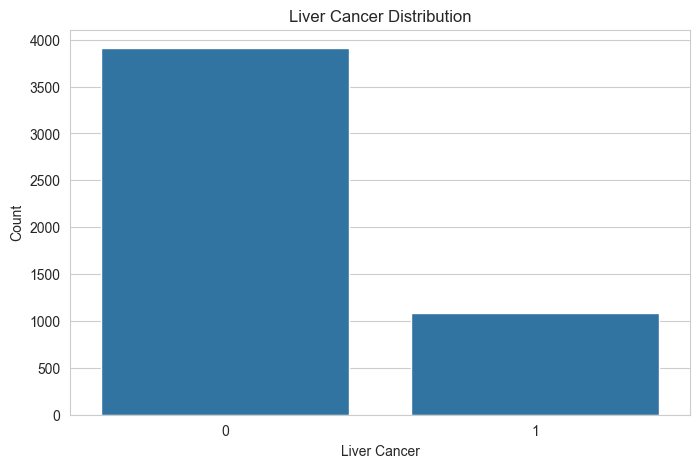

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="liver_cancer"
)

plt.title("Liver Cancer Distribution")
plt.xlabel("Liver Cancer")
plt.ylabel("Count")

plt.show()

## Numerical Feature Distribution

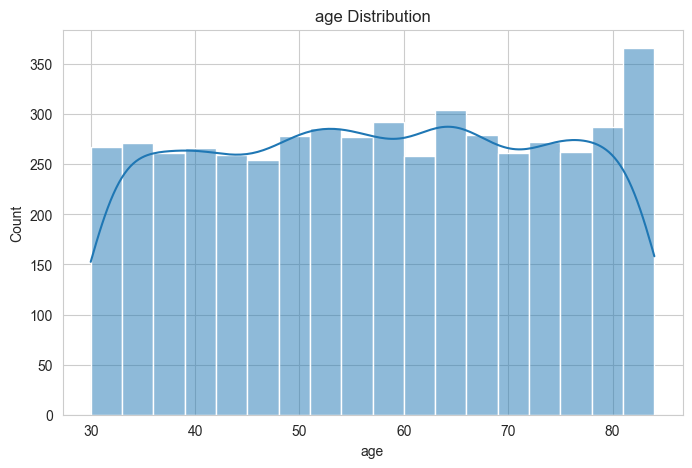

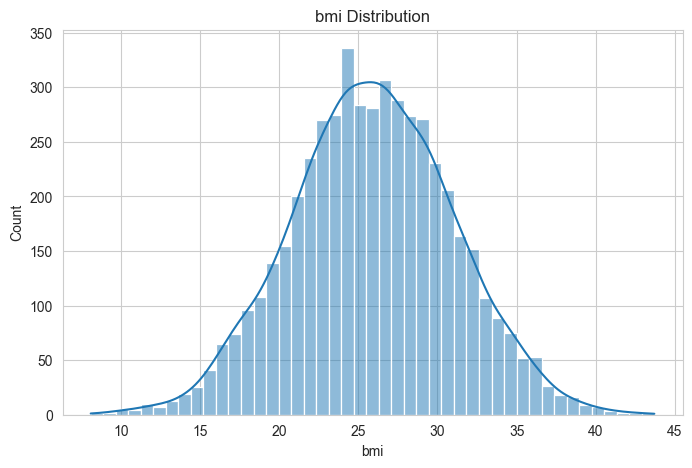

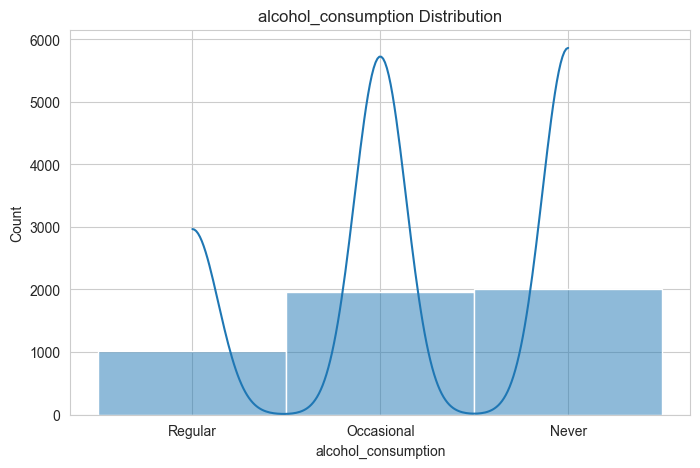

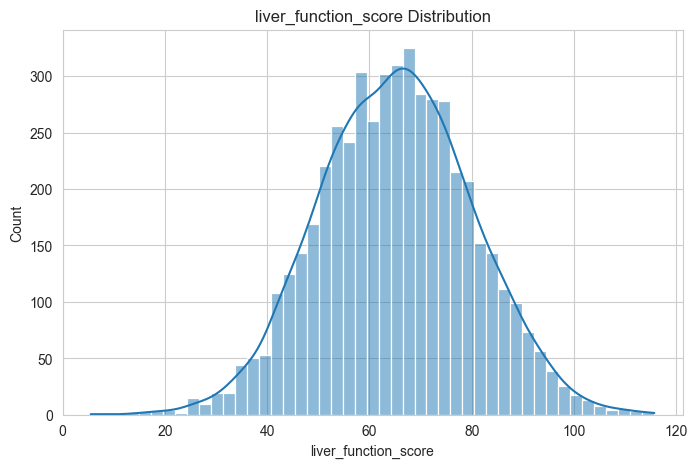

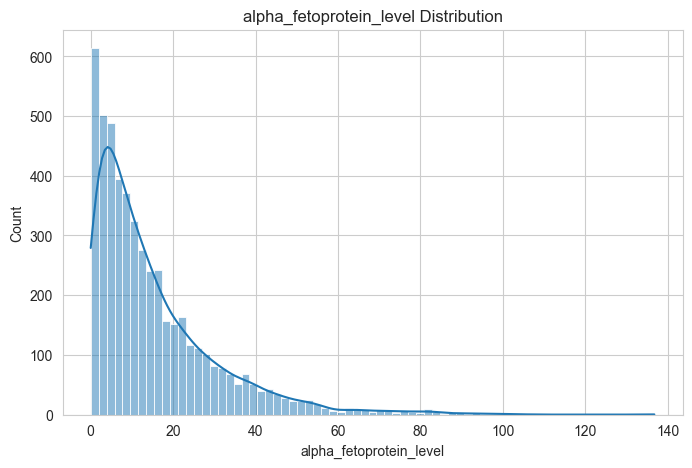

In [23]:
numerical_features = [
    "age",
    "bmi",
    "alcohol_consumption",
    "liver_function_score",
    "alpha_fetoprotein_level"
]

for feature in numerical_features:

    plt.figure(figsize=(8,5))

    sns.histplot(
        data=df,
        x=feature,
        kde=True
    )

    plt.title(f"{feature} Distribution")

    plt.show()

## Categorical Feature Distribution

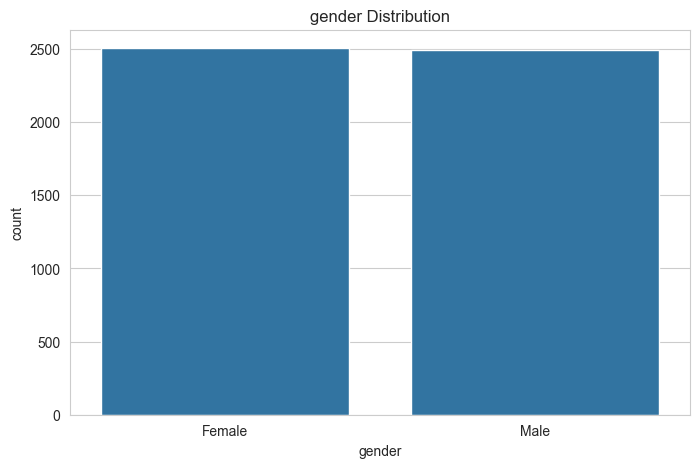

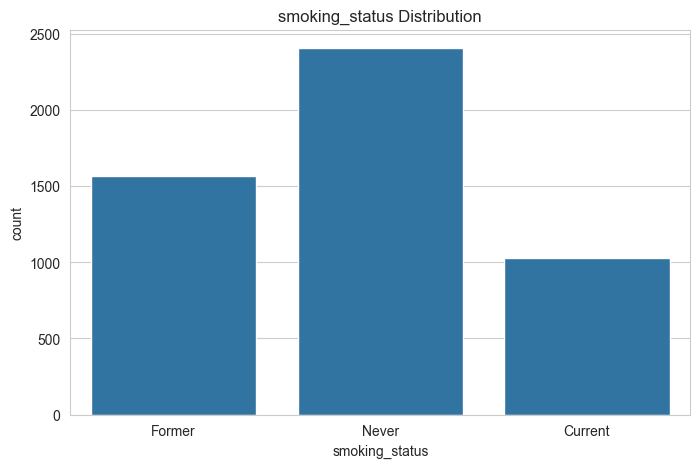

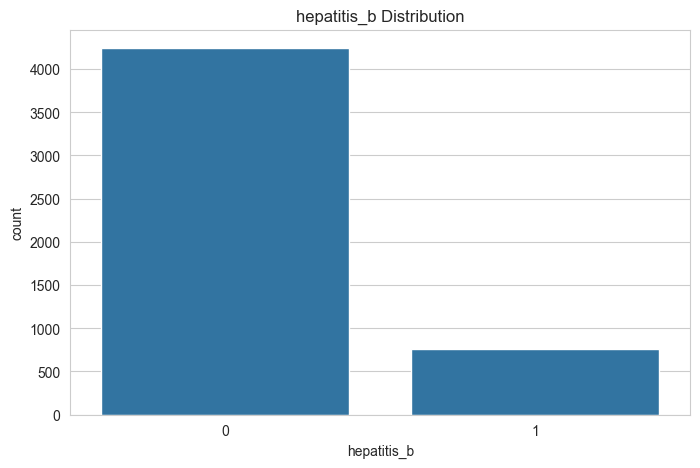

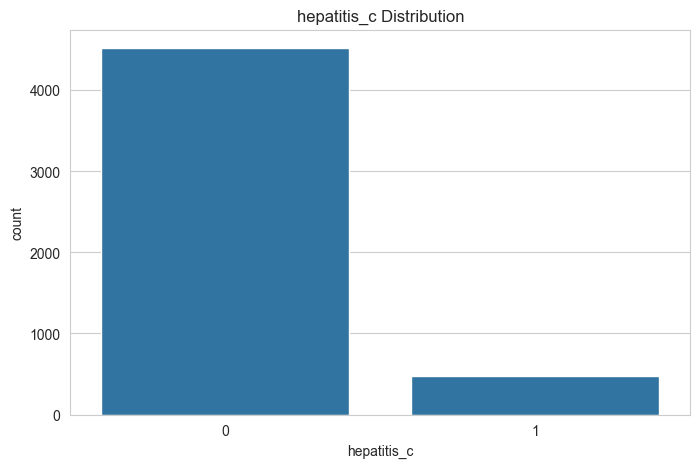

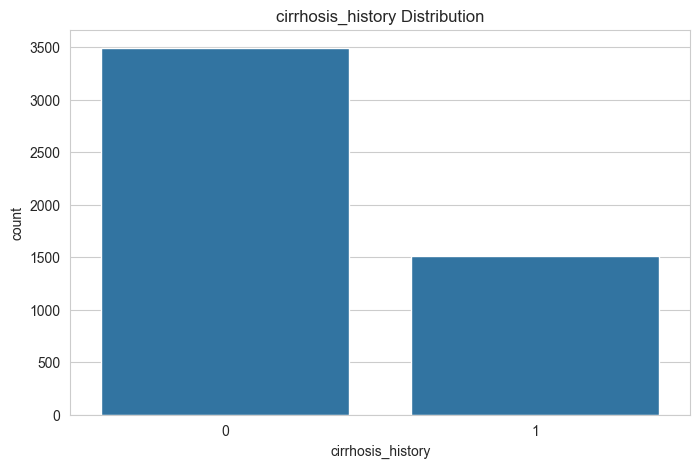

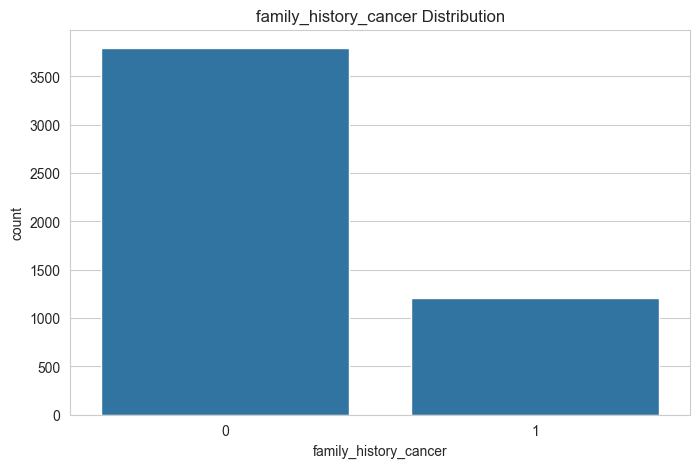

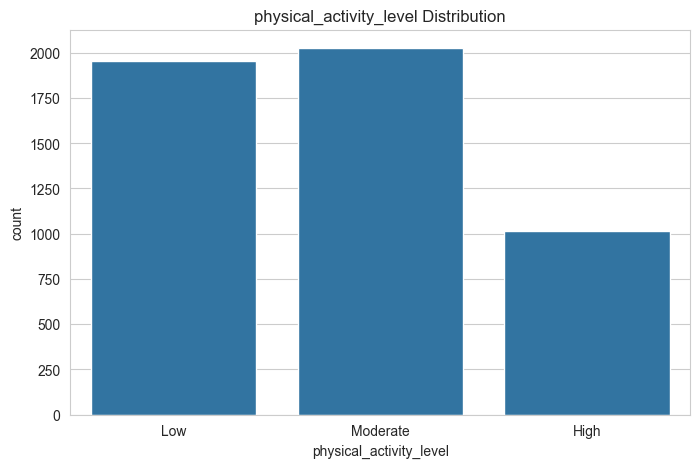

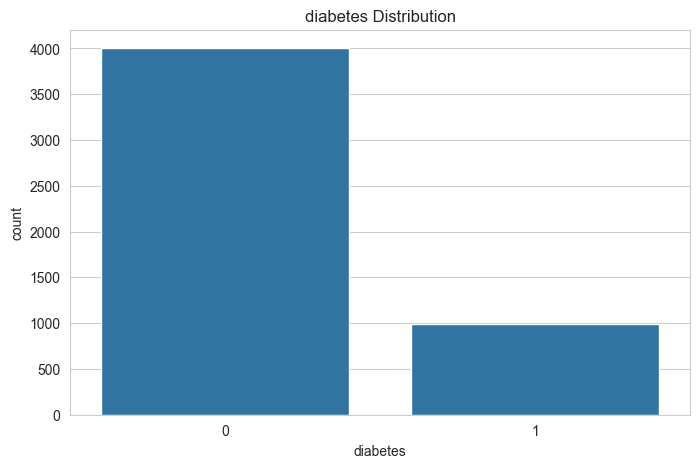

In [24]:
categorical_features = [
    "gender",
    "smoking_status",
    "hepatitis_b",
    "hepatitis_c",
    "cirrhosis_history",
    "family_history_cancer",
    "physical_activity_level",
    "diabetes"
]

for feature in categorical_features:

    plt.figure(figsize=(8,5))

    sns.countplot(
        data=df,
        x=feature
    )

    plt.title(f"{feature} Distribution")
    plt.show()

## Numerical Features vs Liver Cancer

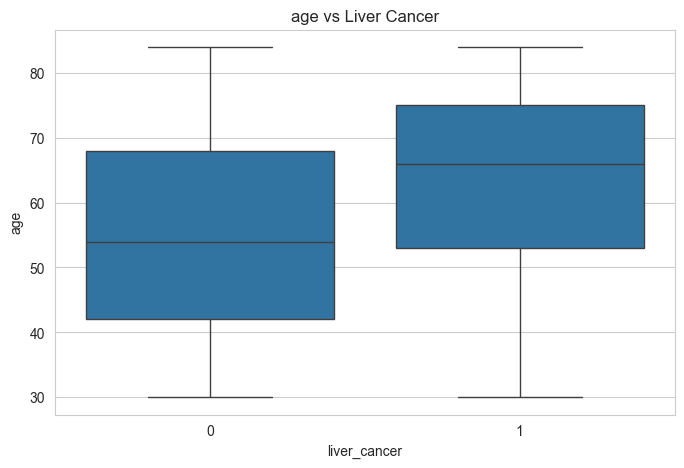

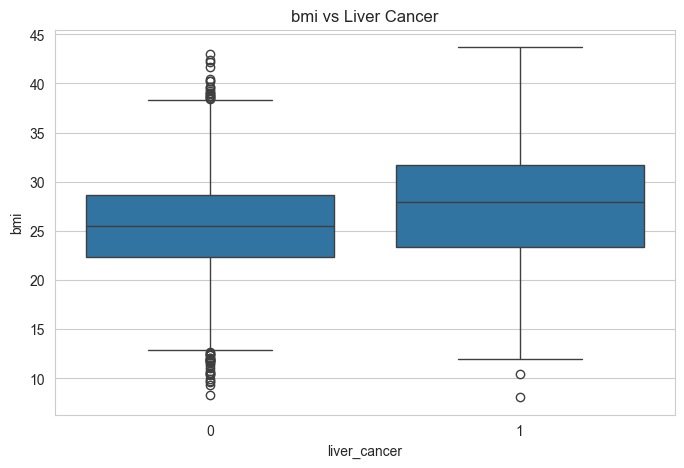

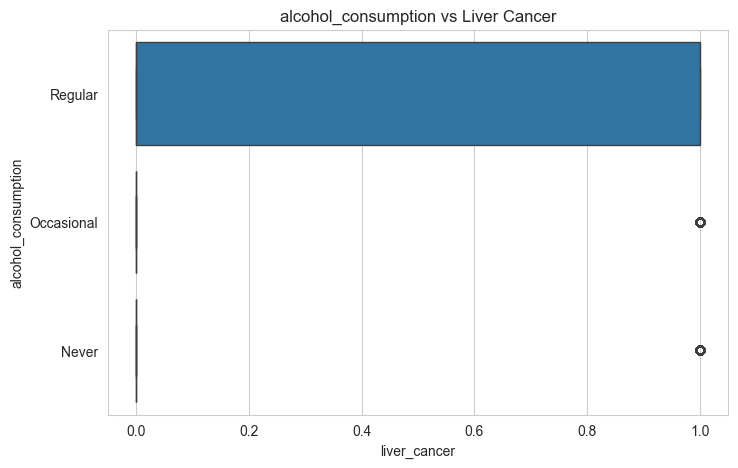

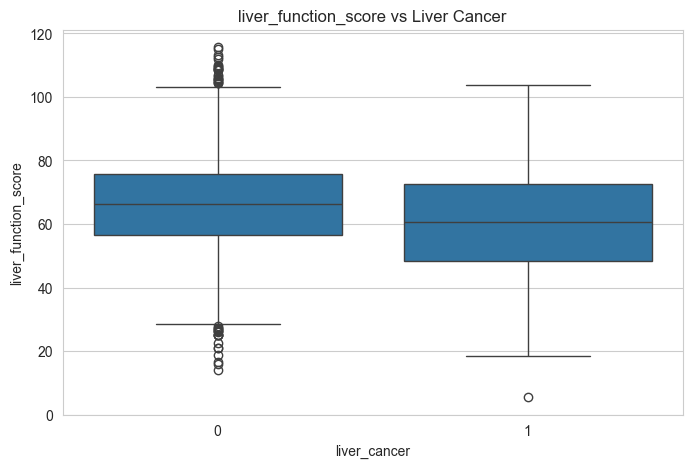

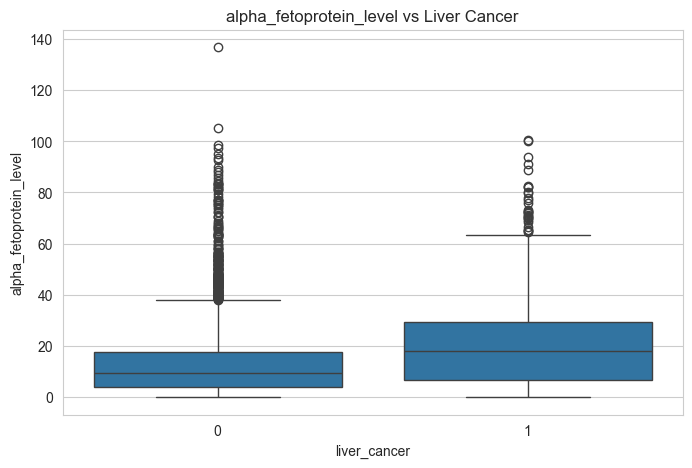

In [25]:
for feature in numerical_features:
    plt.figure(figsize=(8,5))
    sns.boxplot(
        data=df,
        x="liver_cancer",
        y=feature
    )
    plt.title(f"{feature} vs Liver Cancer")
    plt.show()

## Categorical Features vs Liver Cancer

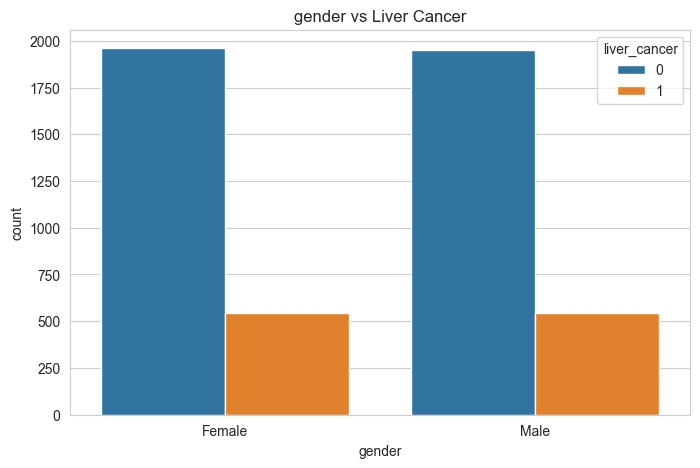

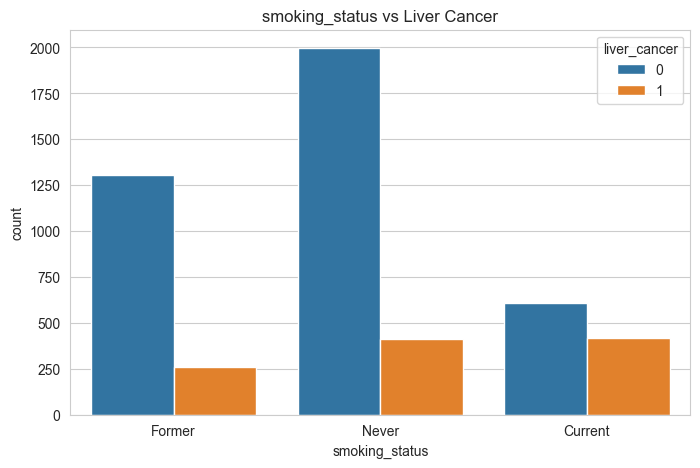

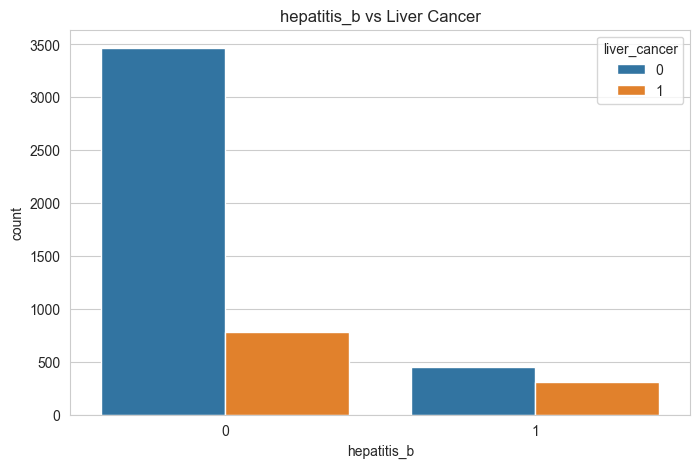

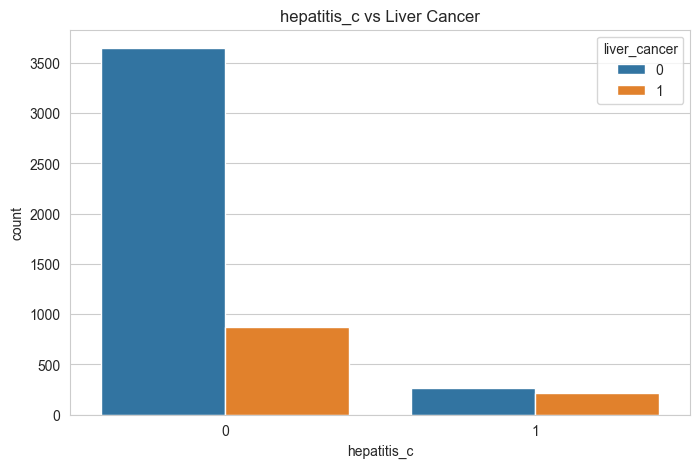

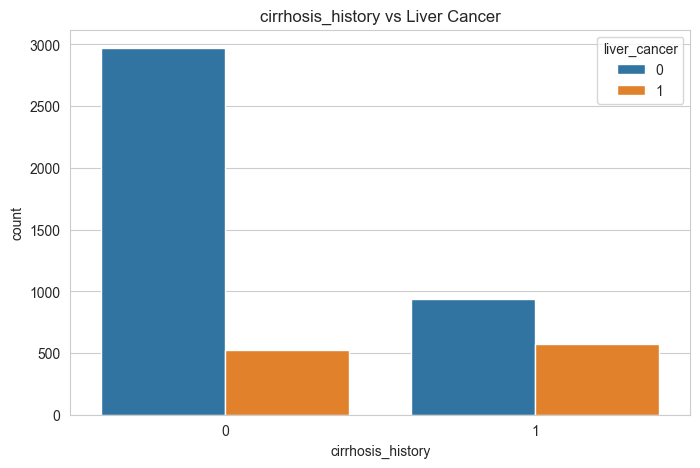

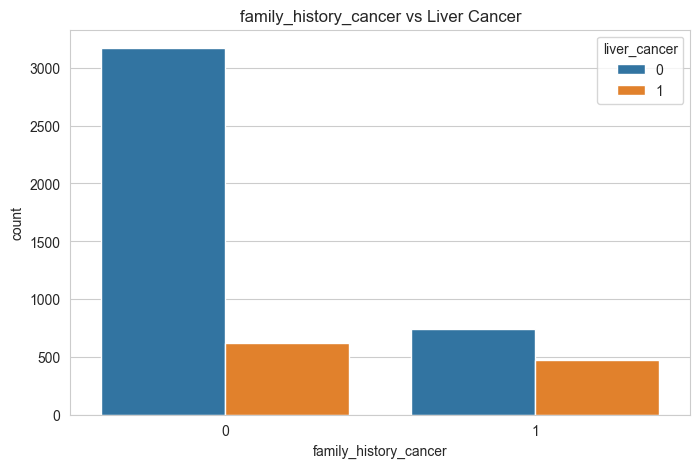

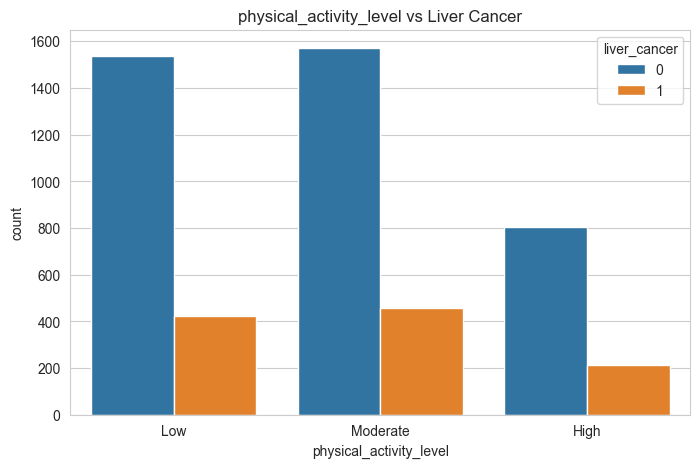

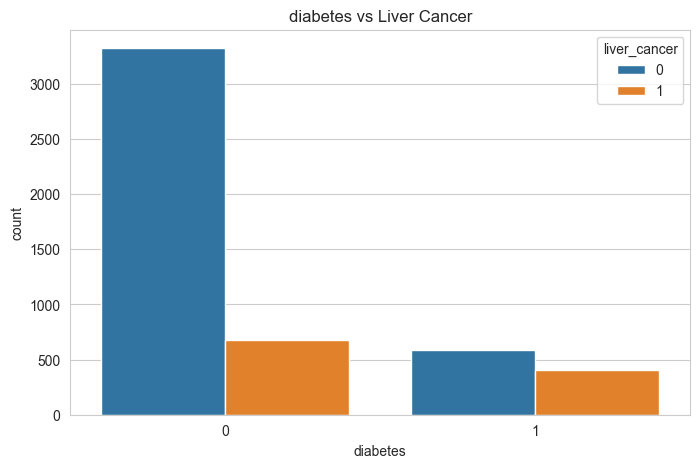

In [26]:
for feature in categorical_features:
    plt.figure(figsize=(8,5))
    sns.countplot(
        data=df,
        x=feature,
        hue="liver_cancer"
    )
    plt.title(f"{feature} vs Liver Cancer")
    plt.show()

## Correlation Heatmap

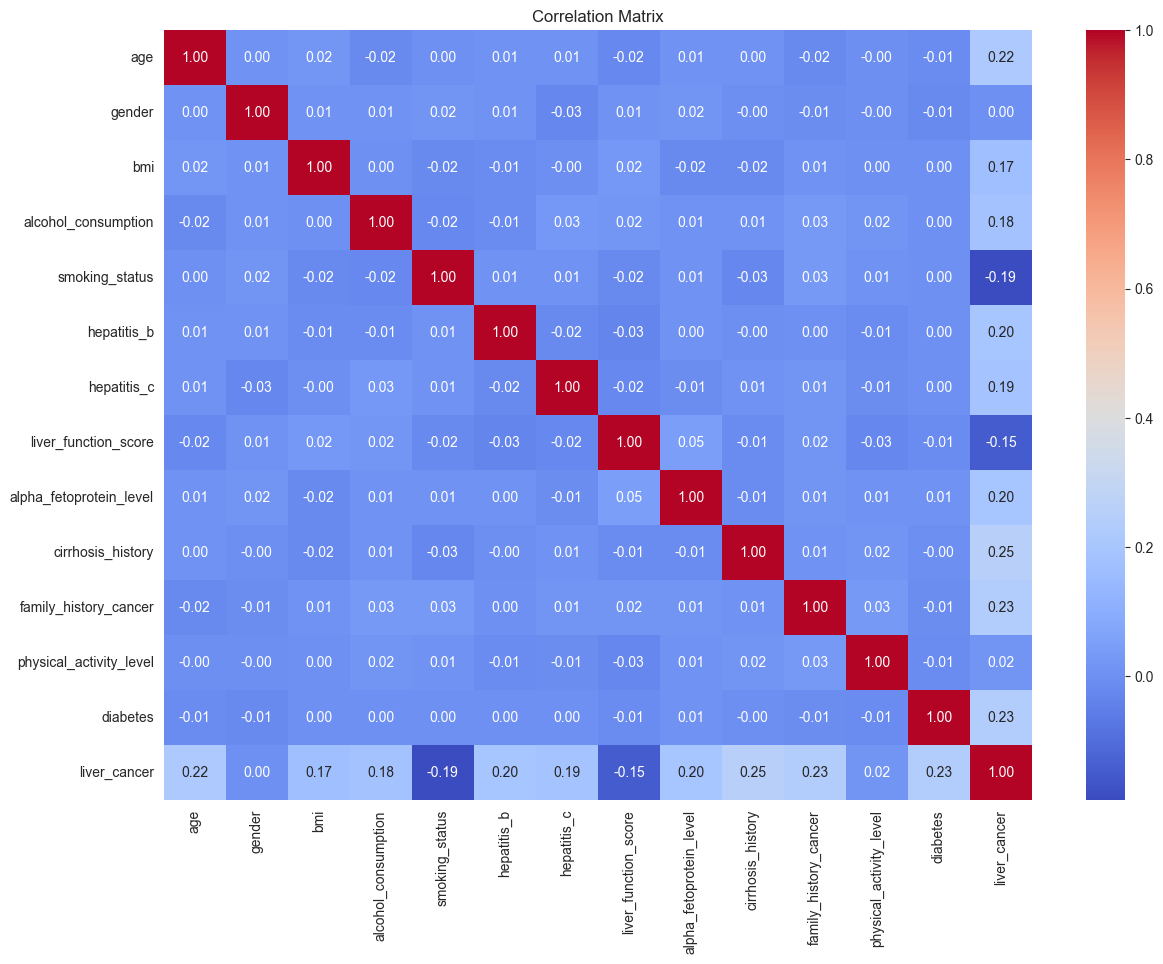

In [28]:
encoded_df = df.copy()
for column in encoded_df.select_dtypes(include="object"):
    encoded_df[column] = (
        encoded_df[column]
        .astype("category")
        .cat.codes
    )
plt.figure(figsize=(14,10))
sns.heatmap(
    encoded_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

## Statistical Testing (T-Test)

In [36]:
for feature in numerical_features:
    cancer_yes = df[df["liver_cancer"] == 1][feature]
    cancer_no = df[df["liver_cancer"] == 0][feature]
    statistic, p_value = ttest_ind(
        cancer_yes,
        cancer_no
    )
    print(f"{feature}")
    print(f"P-value: {p_value}")

age
P-value: 1.9745105621708702e-54
bmi
P-value: 1.4863189110863158e-33


TypeError: unsupported operand type(s) for /: 'str' and 'int'